# Exploratory Data Analysis — Supermarket Sales

## CodeAlpha Data Analytics Internship — Task 2

### Project Overview

This project performs Exploratory Data Analysis (EDA) on a supermarket sales dataset.

The purpose of this analysis is to understand the structure and characteristics of the dataset, identify important trends and patterns, detect anomalies and potential data-quality issues, and investigate relationships between variables using statistical analysis and visualization.

### Objectives

The analysis aims to:

1. Understand the structure and data types of the dataset.
2. Ask meaningful business questions before analysis.
3. Examine distributions, trends, and patterns.
4. Identify anomalies and potential outliers.
5. Detect missing values, duplicates, and other data-quality issues.
6. Test selected hypotheses using statistical analysis and visualization.
7. Generate meaningful insights from the data.

In [127]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from scipy import stats

%matplotlib inline

**Why these libraries?**
| Library    | Purpose                        |
| ---------- | ------------------------------ |
| Pandas     | Data loading and manipulation  |
| NumPy      | Numerical analysis             |
| Matplotlib | Visualization                  |
| Seaborn    | Statistical visualization      |
| SciPy      | Statistical hypothesis testing |


**## 1. Loading the Dataset**

The dataset contains supermarket transaction records that can be explored to understand sales behavior, customer characteristics, product performance, payment methods, and other patterns.

In [128]:
df = pd.read_csv("SuperMarket Analysis.csv")

In [129]:
df.head()

,Invoice ID,Branch,City,Customer type,Gender,Product line,Unit price,Quantity,Tax 5%,Sales,Date,Time,Payment,cogs,gross margin percentage,gross income,Rating
0,750-67-8428,Alex,Yangon,Member,Female,Health and beauty,74.69,7,26.1415,548.9715,1/5/2019,1:08:00 PM,Ewallet,522.83,4.761905,26.1415,9.1
1,226-31-3081,Giza,Naypyitaw,Normal,Female,Electronic accessories,15.28,5,3.8200,80.2200,3/8/2019,10:29:00 AM,Cash,76.40,4.761905,3.8200,9.6
2,631-41-3108,Alex,Yangon,Normal,Female,Home and lifestyle,46.33,7,16.2155,340.5255,3/3/2019,1:23:00 PM,Credit card,324.31,4.761905,16.2155,7.4
3,123-19-1176,Alex,Yangon,Member,Female,Health and beauty,58.22,8,23.2880,489.0480,1/27/2019,8:33:00 PM,Ewallet,465.76,4.761905,23.2880,8.4
4,373-73-7910,Alex,Yangon,Member,Female,Sports and travel,86.31,7,30.2085,634.3785,2/8/2019,10:37:00 AM,Ewallet,604.17,4.761905,30.2085,5.3


## 2. Initial Data Exploration

Before performing detailed analysis, we first examine the dataset structure, dimensions, variables, and data types.

In [130]:
df.shape

(1000, 17)

In [131]:
df.columns

Index(['Invoice ID', 'Branch', 'City', 'Customer type', 'Gender',
       'Product line', 'Unit price', 'Quantity', 'Tax 5%', 'Sales', 'Date',
       'Time', 'Payment', 'cogs', 'gross margin percentage', 'gross income',
       'Rating'],
      dtype='object')

In [132]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 17 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Invoice ID               1000 non-null   object 
 1   Branch                   1000 non-null   object 
 2   City                     1000 non-null   object 
 3   Customer type            1000 non-null   object 
 4   Gender                   1000 non-null   object 
 5   Product line             1000 non-null   object 
 6   Unit price               1000 non-null   float64
 7   Quantity                 1000 non-null   int64  
 8   Tax 5%                   1000 non-null   float64
 9   Sales                    1000 non-null   float64
 10  Date                     1000 non-null   object 
 11  Time                     1000 non-null   object 
 12  Payment                  1000 non-null   object 
 13  cogs                     1000 non-null   float64
 14  gross margin percentage  

In [133]:
df.tail()

,Invoice ID,Branch,City,Customer type,Gender,Product line,Unit price,Quantity,Tax 5%,Sales,Date,Time,Payment,cogs,gross margin percentage,gross income,Rating
995,233-67-5758,Giza,Naypyitaw,Normal,Male,Health and beauty,40.35,1,2.0175,42.3675,1/29/2019,1:46:00 PM,Ewallet,40.35,4.761905,2.0175,6.2
996,303-96-2227,Cairo,Mandalay,Normal,Female,Home and lifestyle,97.38,10,48.6900,1022.4900,3/2/2019,5:16:00 PM,Ewallet,973.80,4.761905,48.6900,4.4
997,727-02-1313,Alex,Yangon,Member,Male,Food and beverages,31.84,1,1.5920,33.4320,2/9/2019,1:22:00 PM,Cash,31.84,4.761905,1.5920,7.7
998,347-56-2442,Alex,Yangon,Normal,Male,Home and lifestyle,65.82,1,3.2910,69.1110,2/22/2019,3:33:00 PM,Cash,65.82,4.761905,3.2910,4.1
999,849-09-3807,Alex,Yangon,Member,Female,Fashion accessories,88.34,7,30.9190,649.2990,2/18/2019,1:28:00 PM,Cash,618.38,4.761905,30.9190,6.6


##  **Analytical Questions**

Before analyzing the data, the following questions were defined:

### Sales and Product Performance
1. Which product lines generate the highest total sales?
2. Which product lines sell the highest quantities?
3. How are sales distributed across branches?

### Customer Behavior
4. How do sales differ between customer types?
5. Are there differences in purchasing behavior between male and female customers?
6. Which payment methods are most frequently used?

### Relationships and Patterns
7. Is there a relationship between quantity purchased and total sales?
8. What relationship exists between gross income and total sales?
9. How are customer ratings distributed?

### Anomalies and Data Quality
10. Are there unusually high or low transaction values?
11. Are there missing values or duplicate records?
12. Are there inconsistent or invalid values in the dataset?

### Hypothesis Testing
13. Is there evidence of a relationship between quantity purchased and total sales?
14. Is there a statistically significant difference in sales between selected customer groups?

In [134]:
df.dtypes

,0
Invoice ID,object
Branch,object
City,object
Customer type,object
Gender,object
Product line,object
Unit price,float64
Quantity,int64
Tax 5%,float64
Sales,float64


In [135]:
df.describe(include="all")

,Invoice ID,Branch,City,Customer type,Gender,Product line,Unit price,Quantity,Tax 5%,Sales,Date,Time,Payment,cogs,gross margin percentage,gross income,Rating
count,1000,1000,1000,1000,1000,1000,1000.000000,1000.000000,1000.000000,1000.000000,1000,1000,1000,1000.00000,1.000000e+03,1000.000000,1000.00000
unique,1000,3,3,2,2,6,NaN,NaN,NaN,NaN,89,506,3,NaN,NaN,NaN,NaN
top,849-09-3807,Alex,Yangon,Member,Female,Fashion accessories,NaN,NaN,NaN,NaN,2/7/2019,7:48:00 PM,Ewallet,NaN,NaN,NaN,NaN
freq,1,340,340,565,571,178,NaN,NaN,NaN,NaN,20,7,345,NaN,NaN,NaN,NaN
mean,NaN,NaN,NaN,NaN,NaN,NaN,55.672130,5.510000,15.379369,322.966749,NaN,NaN,NaN,307.58738,4.761905e+00,15.379369,6.97270
std,NaN,NaN,NaN,NaN,NaN,NaN,26.494628,2.923431,11.708825,245.885335,NaN,NaN,NaN,234.17651,6.131498e-14,11.708825,1.71858
min,NaN,NaN,NaN,NaN,NaN,NaN,10.080000,1.000000,0.508500,10.678500,NaN,NaN,NaN,10.17000,4.761905e+00,0.508500,4.00000
25%,NaN,NaN,NaN,NaN,NaN,NaN,32.875000,3.000000,5.924875,124.422375,NaN,NaN,NaN,118.49750,4.761905e+00,5.924875,5.50000
50%,NaN,NaN,NaN,NaN,NaN,NaN,55.230000,5.000000,12.088000,253.848000,NaN,NaN,NaN,241.76000,4.761905e+00,12.088000,7.00000
75%,NaN,NaN,NaN,NaN,NaN,NaN,77.935000,8.000000,22.445250,471.350250,NaN,NaN,NaN,448.90500,4.761905e+00,22.445250,8.50000


In [136]:
# For numeric variables only
df.describe()

,Unit price,Quantity,Tax 5%,Sales,cogs,gross margin percentage,gross income,Rating
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.00000,1.000000e+03,1000.000000,1000.00000
mean,55.672130,5.510000,15.379369,322.966749,307.58738,4.761905e+00,15.379369,6.97270
std,26.494628,2.923431,11.708825,245.885335,234.17651,6.131498e-14,11.708825,1.71858
min,10.080000,1.000000,0.508500,10.678500,10.17000,4.761905e+00,0.508500,4.00000
25%,32.875000,3.000000,5.924875,124.422375,118.49750,4.761905e+00,5.924875,5.50000
50%,55.230000,5.000000,12.088000,253.848000,241.76000,4.761905e+00,12.088000,7.00000
75%,77.935000,8.000000,22.445250,471.350250,448.90500,4.761905e+00,22.445250,8.50000
max,99.960000,10.000000,49.650000,1042.650000,993.00000,4.761905e+00,49.650000,10.00000


##  **Data Quality Assessment**

We first check the dataset for missing values, duplicate records, and unusual values before proceeding with deeper analysis.

In [137]:
df.isnull().sum()

,0
Invoice ID,0
Branch,0
City,0
Customer type,0
Gender,0
Product line,0
Unit price,0
Quantity,0
Tax 5%,0
Sales,0


In [138]:
# To get total number of the missing values

df.isnull().sum().sum()

np.int64(0)

In [139]:
# Checking Duplicates
df.duplicated().sum()

np.int64(0)

In [140]:
# Check unique values
categorical_columns = df.select_dtypes(include="object").columns

for column in categorical_columns:
    print(f"\n{column}")
    print(df[column].unique())


Invoice ID
['750-67-8428' '226-31-3081' '631-41-3108' '123-19-1176' '373-73-7910'
 '699-14-3026' '355-53-5943' '315-22-5665' '665-32-9167' '692-92-5582'
 '351-62-0822' '529-56-3974' '365-64-0515' '252-56-2699' '829-34-3910'
 '299-46-1805' '656-95-9349' '765-26-6951' '329-62-1586' '319-50-3348'
 '300-71-4605' '371-85-5789' '273-16-6619' '636-48-8204' '549-59-1358'
 '227-03-5010' '649-29-6775' '189-17-4241' '145-94-9061' '848-62-7243'
 '871-79-8483' '149-71-6266' '640-49-2076' '595-11-5460' '183-56-6882'
 '232-16-2483' '129-29-8530' '272-65-1806' '333-73-7901' '777-82-7220'
 '280-35-5823' '554-53-8700' '354-25-5821' '228-96-1411' '617-15-4209'
 '132-32-9879' '370-41-7321' '727-46-3608' '669-54-1719' '574-22-5561'
 '326-78-5178' '162-48-8011' '616-24-2851' '778-71-5554' '242-55-6721'
 '399-46-5918' '106-35-6779' '635-40-6220' '817-48-8732' '120-06-4233'
 '285-68-5083' '803-83-5989' '347-34-2234' '199-75-8169' '853-23-2453'
 '877-22-3308' '838-78-4295' '109-28-2512' '232-11-3025' '382-03-

##  Descriptive Statistics

Descriptive statistics provide an initial understanding of the numerical variables in the dataset. We examine measures such as count, mean, standard deviation, minimum, maximum, and quartiles.

In [141]:
df.describe()

,Unit price,Quantity,Tax 5%,Sales,cogs,gross margin percentage,gross income,Rating
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.00000,1.000000e+03,1000.000000,1000.00000
mean,55.672130,5.510000,15.379369,322.966749,307.58738,4.761905e+00,15.379369,6.97270
std,26.494628,2.923431,11.708825,245.885335,234.17651,6.131498e-14,11.708825,1.71858
min,10.080000,1.000000,0.508500,10.678500,10.17000,4.761905e+00,0.508500,4.00000
25%,32.875000,3.000000,5.924875,124.422375,118.49750,4.761905e+00,5.924875,5.50000
50%,55.230000,5.000000,12.088000,253.848000,241.76000,4.761905e+00,12.088000,7.00000
75%,77.935000,8.000000,22.445250,471.350250,448.90500,4.761905e+00,22.445250,8.50000
max,99.960000,10.000000,49.650000,1042.650000,993.00000,4.761905e+00,49.650000,10.00000


In [142]:
# Examining the main numeric variables
numeric_columns = df.select_dtypes(include=np.number).columns

for column in numeric_columns:
    print(f"\n--- {column} ---")
    print(f"Mean: {df[column].mean():.2f}")
    print(f"Median: {df[column].median():.2f}")
    print(f"Standard Deviation: {df[column].std():.2f}")
    print(f"Minimum: {df[column].min():.2f}")
    print(f"Maximum: {df[column].max():.2f}")


--- Unit price ---
Mean: 55.67
Median: 55.23
Standard Deviation: 26.49
Minimum: 10.08
Maximum: 99.96

--- Quantity ---
Mean: 5.51
Median: 5.00
Standard Deviation: 2.92
Minimum: 1.00
Maximum: 10.00

--- Tax 5% ---
Mean: 15.38
Median: 12.09
Standard Deviation: 11.71
Minimum: 0.51
Maximum: 49.65

--- Sales ---
Mean: 322.97
Median: 253.85
Standard Deviation: 245.89
Minimum: 10.68
Maximum: 1042.65

--- cogs ---
Mean: 307.59
Median: 241.76
Standard Deviation: 234.18
Minimum: 10.17
Maximum: 993.00

--- gross margin percentage ---
Mean: 4.76
Median: 4.76
Standard Deviation: 0.00
Minimum: 4.76
Maximum: 4.76

--- gross income ---
Mean: 15.38
Median: 12.09
Standard Deviation: 11.71
Minimum: 0.51
Maximum: 49.65

--- Rating ---
Mean: 6.97
Median: 7.00
Standard Deviation: 1.72
Minimum: 4.00
Maximum: 10.00


## Categorical Variable Analysis

 Categorical variables are examined using frequency counts to understand the composition of transactions across branches, product lines, customer types, genders, and payment methods.

In [143]:
categorical_columns = df.select_dtypes(include="object").columns

for column in categorical_columns:
    print(f"\n--- {column} ---")
    print(df[column].value_counts())


--- Invoice ID ---
Invoice ID
849-09-3807    1
750-67-8428    1
226-31-3081    1
631-41-3108    1
123-19-1176    1
              ..
365-64-0515    1
529-56-3974    1
351-62-0822    1
692-92-5582    1
665-32-9167    1
Name: count, Length: 1000, dtype: int64

--- Branch ---
Branch
Alex     340
Cairo    332
Giza     328
Name: count, dtype: int64

--- City ---
City
Yangon       340
Mandalay     332
Naypyitaw    328
Name: count, dtype: int64

--- Customer type ---
Customer type
Member    565
Normal    435
Name: count, dtype: int64

--- Gender ---
Gender
Female    571
Male      429
Name: count, dtype: int64

--- Product line ---
Product line
Fashion accessories       178
Food and beverages        174
Electronic accessories    170
Sports and travel         166
Home and lifestyle        160
Health and beauty         152
Name: count, dtype: int64

--- Date ---
Date
2/7/2019     20
2/15/2019    19
3/2/2019     18
1/8/2019     18
3/14/2019    18
             ..
2/1/2019      6
1/4/2019      6
3/

Now let's answer our first important business question:

**Which product lines generate the highest sales?**





In [144]:
df.columns.tolist()

['Invoice ID',
 'Branch',
 'City',
 'Customer type',
 'Gender',
 'Product line',
 'Unit price',
 'Quantity',
 'Tax 5%',
 'Sales',
 'Date',
 'Time',
 'Payment',
 'cogs',
 'gross margin percentage',
 'gross income',
 'Rating']

In [145]:

product_sales = (
    df.groupby("Product line")["Sales"]
    .sum()
    .sort_values(ascending=False)
)

product_sales

,Sales
Product line,
Food and beverages,56144.8440
Sports and travel,55122.8265
Electronic accessories,54337.5315
Fashion accessories,54305.8950
Home and lifestyle,53861.9130
Health and beauty,49193.7390


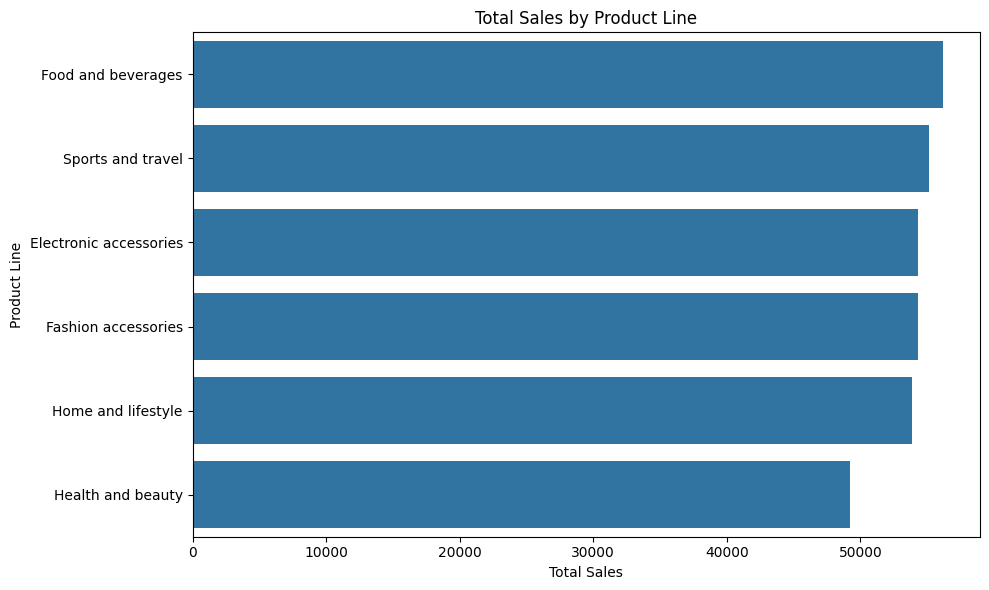

In [146]:
plt.figure(figsize=(10, 6))

sns.barplot(
    x=product_sales.values,
    y=product_sales.index
)

plt.title("Total Sales by Product Line")
plt.xlabel("Total Sales")
plt.ylabel("Product Line")
plt.tight_layout()
plt.show()

**highest-selling product line**

*   Food and beverages


**lowest-selling product line**


*   Health and beauty

**Approximate difference between them is** 6951

# **Quantity sold by product line**

Question:

**Which product lines have the highest sales volume?**

In [147]:
product_quantity = (
    df.groupby("Product line")["Quantity"]
    .sum()
    .sort_values(ascending=False)
)

product_quantity

,Quantity
Product line,
Electronic accessories,971
Food and beverages,952
Sports and travel,920
Home and lifestyle,911
Fashion accessories,902
Health and beauty,854


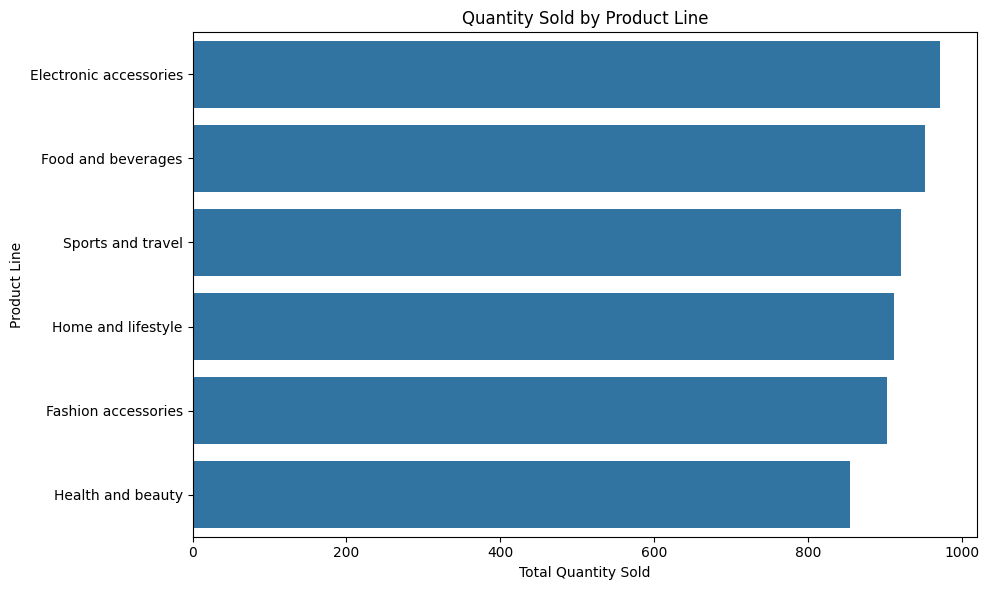

In [148]:
plt.figure(figsize=(10, 6))

sns.barplot(
    x=product_quantity.values,
    y=product_quantity.index
)

plt.title("Quantity Sold by Product Line")
plt.xlabel("Total Quantity Sold")
plt.ylabel("Product Line")
plt.tight_layout()
plt.show()

# **Branch analysis**

Question:

**How are sales distributed across branches?**

In [149]:
branch_sales = (
    df.groupby("Branch")["Sales"]
    .sum()
    .sort_values(ascending=False)
)

branch_sales

,Sales
Branch,
Giza,110568.7065
Alex,106200.3705
Cairo,106197.6720


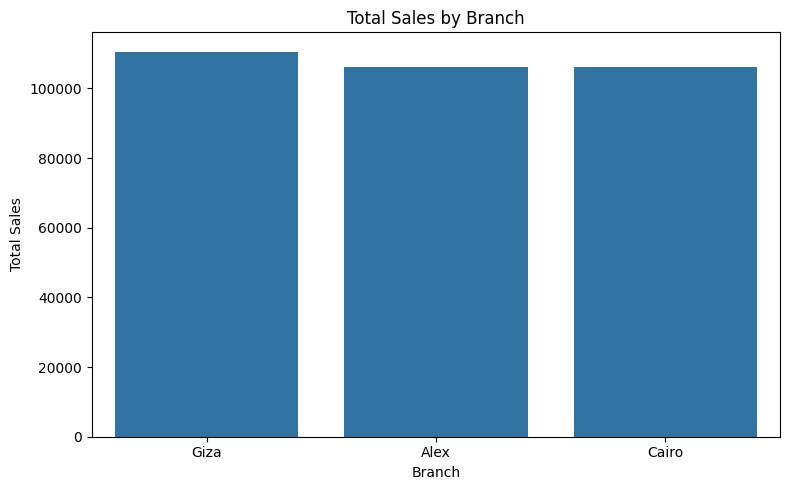

In [150]:
plt.figure(figsize=(8, 5))

sns.barplot(
    x=branch_sales.index,
    y=branch_sales.values
)

plt.title("Total Sales by Branch")
plt.xlabel("Branch")
plt.ylabel("Total Sales")
plt.tight_layout()
plt.show()

# **Customer type analysis**

Question:

How do sales differ between customer types?

In [151]:
customer_sales = (
    df.groupby("Customer type")["Sales"]
    .agg(["sum", "mean", "count"])
)

customer_sales

,sum,mean,count
Customer type,,,
Member,189694.764,335.742945,565
Normal,133271.985,306.372379,435


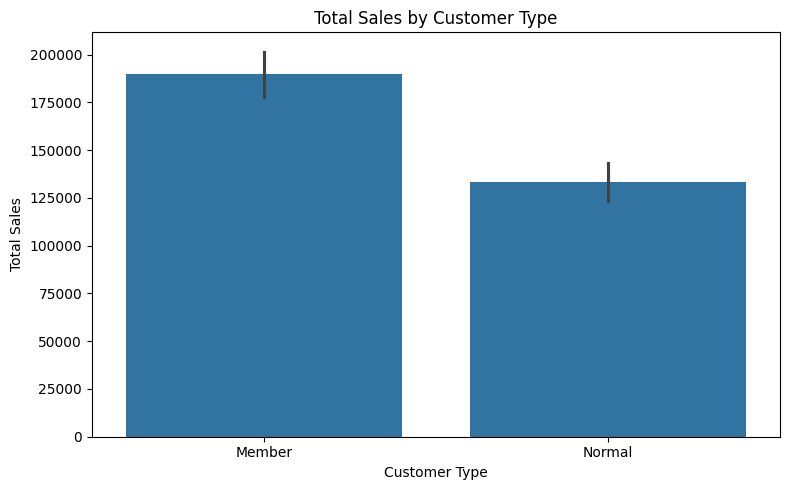

In [152]:
plt.figure(figsize=(8, 5))

sns.barplot(
    data=df,
    x="Customer type",
    y="Sales",
    estimator="sum"
)

plt.title("Total Sales by Customer Type")
plt.xlabel("Customer Type")
plt.ylabel("Total Sales")
plt.tight_layout()
plt.show()

# **Payment method**

Question:

Which payment methods are most frequently used?

In [153]:
payment_counts = df["Payment"].value_counts()

payment_counts

,count
Payment,
Ewallet,345
Cash,344
Credit card,311


# **Relationship between Quantity and Total**

This is important because it begins moving us from simple descriptive analysis toward relationships and statistical analysis.

Question:

Is there a relationship between quantity purchased and total sales?

# Using a scatter plot:

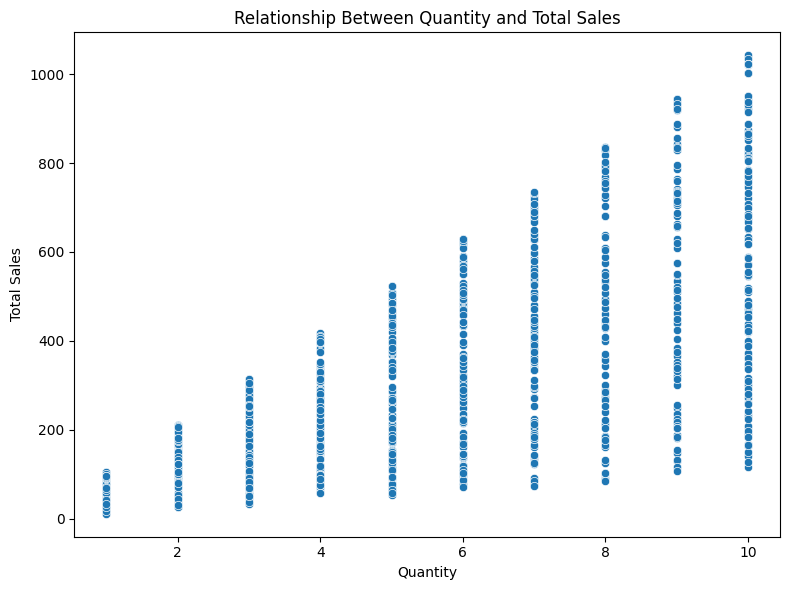

In [154]:
plt.figure(figsize=(8, 6))

sns.scatterplot(
    data=df,
    x="Quantity",
    y="Sales"
)

plt.title("Relationship Between Quantity and Total Sales")
plt.xlabel("Quantity")
plt.ylabel("Total Sales")
plt.tight_layout()
plt.show()

 **calculating correlation:**

In [155]:
correlation = df["Quantity"].corr(df["Sales"])

print(f"Correlation between Quantity and Total Sales: {correlation:.3f}")

Correlation between Quantity and Total Sales: 0.706


# **Correlation matrix**

examining relationships among numerical variables.

In [156]:
correlation_matrix = df.select_dtypes(include=np.number).corr()

correlation_matrix

,Unit price,Quantity,Tax 5%,Sales,cogs,gross margin percentage,gross income,Rating
Unit price,1.000000,0.010778,0.633962,0.633962,0.633962,NaN,0.633962,-0.008778
Quantity,0.010778,1.000000,0.705510,0.705510,0.705510,NaN,0.705510,-0.015815
Tax 5%,0.633962,0.705510,1.000000,1.000000,1.000000,NaN,1.000000,-0.036442
Sales,0.633962,0.705510,1.000000,1.000000,1.000000,NaN,1.000000,-0.036442
cogs,0.633962,0.705510,1.000000,1.000000,1.000000,NaN,1.000000,-0.036442
gross margin percentage,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
gross income,0.633962,0.705510,1.000000,1.000000,1.000000,NaN,1.000000,-0.036442
Rating,-0.008778,-0.015815,-0.036442,-0.036442,-0.036442,NaN,-0.036442,1.000000


# **Detect anomalies and outliers**


Investigating the Sales variable.

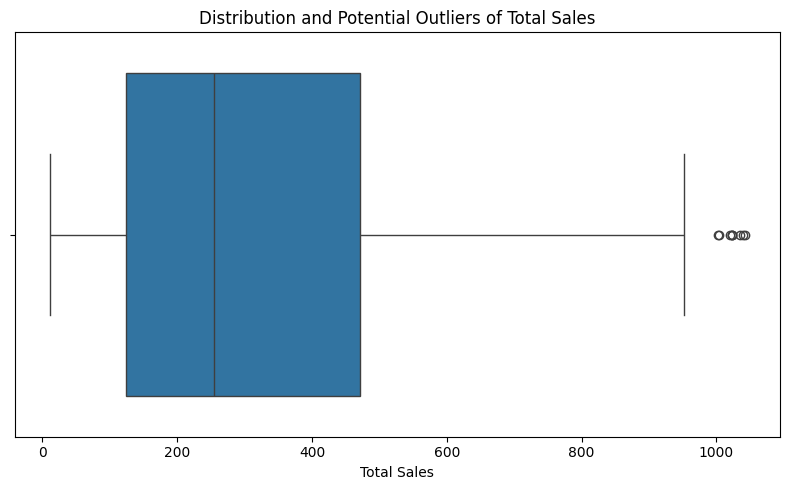

In [157]:
plt.figure(figsize=(8, 5))

sns.boxplot(x=df["Sales"])

plt.title("Distribution and Potential Outliers of Total Sales")
plt.xlabel("Total Sales")
plt.tight_layout()
plt.show()

Now calculating the IQR:

In [158]:

Q1 = df["Sales"].quantile(0.25)
Q3 = df["Sales"].quantile(0.75)

IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

print("Q1:", Q1)
print("Q3:", Q3)
print("IQR:", IQR)
print("Lower bound:", lower_bound)
print("Upper bound:", upper_bound)

Q1: 124.422375
Q3: 471.35024999999996
IQR: 346.927875
Lower bound: -395.9694375
Upper bound: 991.7420625


Finding potential outliers:

In [159]:
outliers = df[
    (df["Sales"] < lower_bound) |
    (df["Sales"] > upper_bound)
]

print("Number of potential outliers:", len(outliers))

Number of potential outliers: 9


In [160]:
outliers[["Product line", "Quantity", "Sales"]].head(20)

,Product line,Quantity,Sales
166,Home and lifestyle,10,1003.590
167,Fashion accessories,10,1039.290
350,Fashion accessories,10,1042.650
357,Sports and travel,10,1002.120
422,Fashion accessories,10,1020.705
557,Food and beverages,10,1034.460
699,Home and lifestyle,10,1023.750
792,Home and lifestyle,10,1022.385
996,Home and lifestyle,10,1022.490


**Important**

An outlier is not automatically an error.

For example, a very large transaction could be a legitimate purchase. We'll describe it as a potential outlier/anomaly unless we have evidence that it is incorrect.

# **Hypothesis testing**

Now we'll satisfy one of the most important CodeAlpha requirements: testing a hypothesis using statistics.

We'll investigate whether customer type is associated with differences in average total sales.

First calculating the groups:

In [161]:
member_sales = df.loc[
    df["Customer type"] == "Member",
    "Sales"
]

normal_sales = df.loc[
    df["Customer type"] == "Normal",
    "Sales"
]

print("Member mean:", member_sales.mean())
print("Normal mean:", normal_sales.mean())

Member mean: 335.74294513274333
Normal mean: 306.3723793103448


### **Hypothesis Test**

**Null Hypothesis (H₀):** There is no statistically significant difference in average transaction value between Member and Normal customers.

**Alternative Hypothesis (H₁):** There is a statistically significant difference in average transaction value between Member and Normal customers.

An independent two-sample t-test will be used to compare the two groups.

In [162]:
t_stat, p_value = stats.ttest_ind(
    member_sales,
    normal_sales,
    equal_var=False
)

print("T-statistic:", t_stat)
print("P-value:", p_value)

T-statistic: 1.8862430247260686
P-value: 0.05956597404441608


In [163]:
alpha = 0.05

if p_value < alpha:
    print("Reject H₀: The difference is statistically significant.")
else:
    print("Fail to reject H₀: There is insufficient evidence of a statistically significant difference.")

Fail to reject H₀: There is insufficient evidence of a statistically significant difference.


### **Key Findings**

### 1. Sales Performance
Food and beverages generated the highest total sales at approximately 56,144.84, while health and beauty generated the lowest at approximately 49,193.74.

### 2. Product Quantity
Electronic accessories had the highest quantity sold with 971 units, whereas health and beauty had the lowest with 854 units.

The product line with the highest quantity sold was not the same as the product line with the highest total sales, indicating that sales performance depends on more than sales volume alone.

### 3. Branch Performance
Giza generated the highest total sales at approximately 110,568.71. Alex and Cairo had almost identical sales totals.

### 4. Customer Behavior
Member customers accounted for 565 transactions compared with 435 transactions from Normal customers. Members also had a higher average transaction value (335.74 compared with 306.37).

### 5. Payment Behavior
E-wallet was the most frequently used payment method with 345 transactions, followed closely by cash with 344 transactions. Credit card was used 311 times.

### 6. Relationship Between Quantity and Sales
Quantity and total sales showed a positive correlation of 0.706, indicating that larger quantities purchased were generally associated with higher transaction values.

### 7. Potential Anomalies
Several high-value transactions were identified as potential outliers. These records should be investigated further to determine whether they represent legitimate large purchases or data-quality issues.

### 8. Hypothesis Testing
An independent two-sample t-test was used to compare average transaction values between Member and Normal customers.

The test produced a t-statistic of 1.8862 and a p-value of 0.05957. Since the p-value is greater than the 0.05 significance level, the null hypothesis was not rejected. Therefore, there is insufficient statistical evidence to conclude that average transaction values differ significantly between the two customer groups.

# **Convert Date and Time**

Because the dataset has Date and Time, first inspect the exact columns:

In [164]:
df['Time']

,Time
0,1:08:00 PM
1,10:29:00 AM
2,1:23:00 PM
3,8:33:00 PM
4,10:37:00 AM
...,...
995,1:46:00 PM
996,5:16:00 PM
997,1:22:00 PM
998,3:33:00 PM


In [165]:
df["Time"] = pd.to_datetime(df["Time"], format="%I:%M:%S %p").dt.time


In [166]:
df["Time"].head()

,Time
0,13:08:00
1,10:29:00
2,13:23:00
3,20:33:00
4,10:37:00


# **Create an hour variable**

Create a new column:

In [167]:
df["Hour"] = pd.to_datetime(
    df["Time"].astype(str)
).dt.hour

/tmp/ipykernel_661/12349645.py:1: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df["Hour"] = pd.to_datetime(


In [175]:
# Check
df[["Time", "Hour"]].head(20)

,Time,Hour
0,13:08:00,13
1,10:29:00,10
2,13:23:00,13
3,20:33:00,20
4,10:37:00,10
5,18:30:00,18
6,14:36:00,14
7,11:38:00,11
8,17:15:00,17
9,13:27:00,13


# **Time-Based Sales Analysis**

To identify temporal patterns in customer transactions, the transaction time was converted into an hourly variable. Sales were then aggregated by hour to identify periods with higher or lower sales activity.

In [171]:
hourly_sales_chrono = df.groupby("Hour")["Sales"].sum().sort_index()

hourly_sales_chrono

,Sales
Hour,
10,31421.4810
11,30377.3295
12,26065.8825
13,34723.2270
14,30828.3990
15,31179.5085
16,25226.3235
17,24445.2180
18,26030.3400


# Visualize hourly **sales**

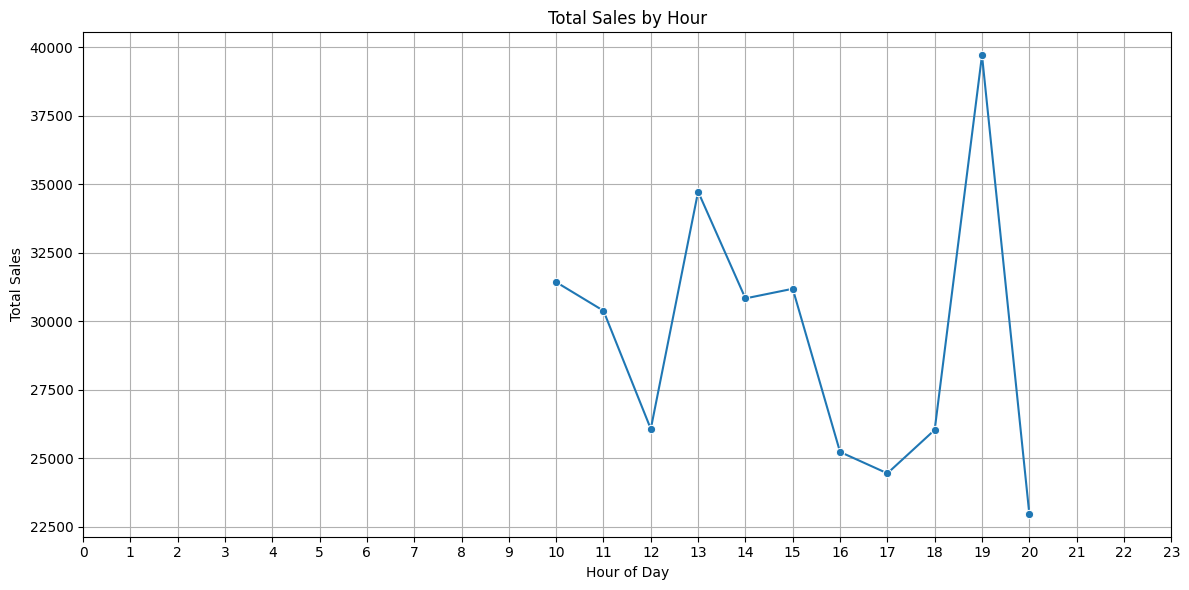

In [172]:
plt.figure(figsize=(12, 6))

sns.lineplot(
    x=hourly_sales_chrono.index,
    y=hourly_sales_chrono.values,
    marker="o"
)

plt.title("Total Sales by Hour")
plt.xlabel("Hour of Day")
plt.ylabel("Total Sales")
plt.xticks(range(0, 24))
plt.grid(True)
plt.tight_layout()
plt.show()

In [176]:
# the peak sales hour
peak_hour = hourly_sales_chrono.idxmax()
peak_sales = hourly_sales_chrono.max()

print("Peak sales hour:", peak_hour)
print("Total sales during peak hour:", round(peak_sales, 2))

Peak sales hour: 19
Total sales during peak hour: 39699.51


In [177]:
# The lowest

lowest_hour = hourly_sales_chrono.idxmin()
lowest_sales = hourly_sales_chrono.min()

print("Lowest sales hour:", lowest_hour)
print("Total sales during lowest hour:", round(lowest_sales, 2))


Lowest sales hour: 20
Total sales during lowest hour: 22969.53


# Analyze transaction volume by hour

Sales value and transaction volume are not the same thing.

Let's see how many transactions occurred during each hour:

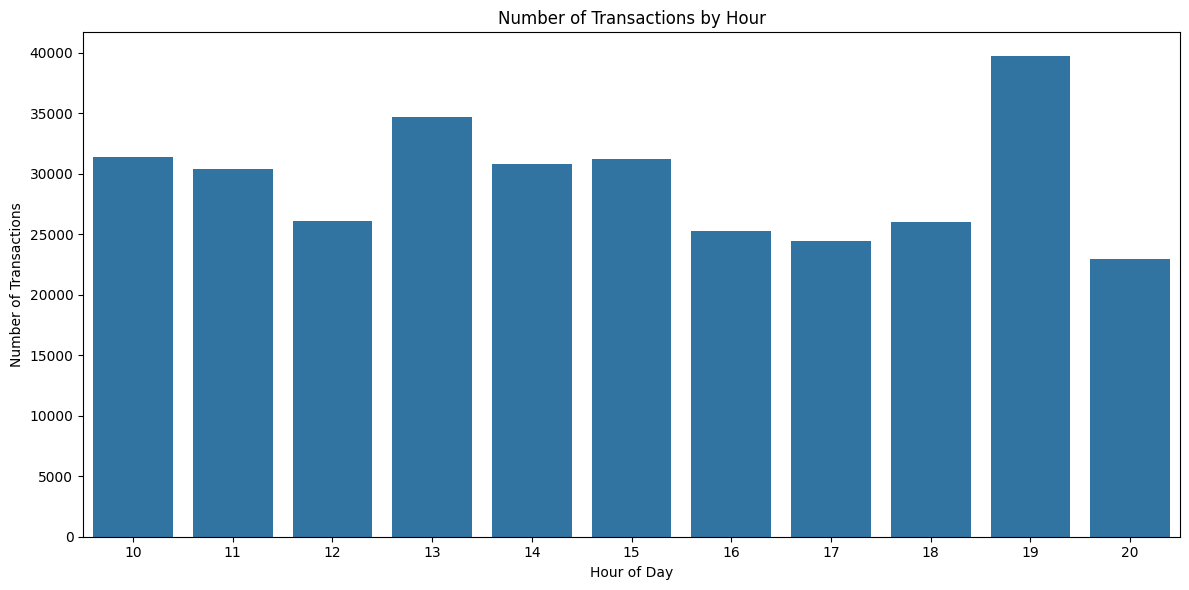

In [179]:
plt.figure(figsize=(12, 6))

sns.barplot(
    x=hourly_sales_chrono.index,
    y=hourly_sales_chrono.values
)

plt.title("Number of Transactions by Hour")
plt.xlabel("Hour of Day")
plt.ylabel("Number of Transactions")
plt.tight_layout()
plt.show()

# **Analyze the Date column**

Your dataset should also contain a Date column.

In [180]:
df["Date"].dtype

dtype('<M8[ns]')

In [181]:
df["Date"] = pd.to_datetime(df["Date"])

# Create day-of-week information

In [183]:
# Create a Day column

df["Day"] = df["Date"].dt.day_name()

# show the first 10

df[["Date", "Day"]].head()

# Group the "Day" by "Sales"
daily_sales = df.groupby("Day")["Sales"].sum()

daily_sales

,Sales
Day,
Friday,43926.3405
Monday,37899.0780
Saturday,56120.8095
Sunday,44457.8925
Thursday,45349.2480
Tuesday,51482.2455
Wednesday,43731.1350


Because the days may appear alphabetically, arrange them chronologically:

In [184]:
day_order = [
    "Monday",
    "Tuesday",
    "Wednesday",
    "Thursday",
    "Friday",
    "Saturday",
    "Sunday"
]

daily_sales = daily_sales.reindex(day_order)

daily_sales

,Sales
Day,
Monday,37899.0780
Tuesday,51482.2455
Wednesday,43731.1350
Thursday,45349.2480
Friday,43926.3405
Saturday,56120.8095
Sunday,44457.8925


**Visualize Sales by Day**

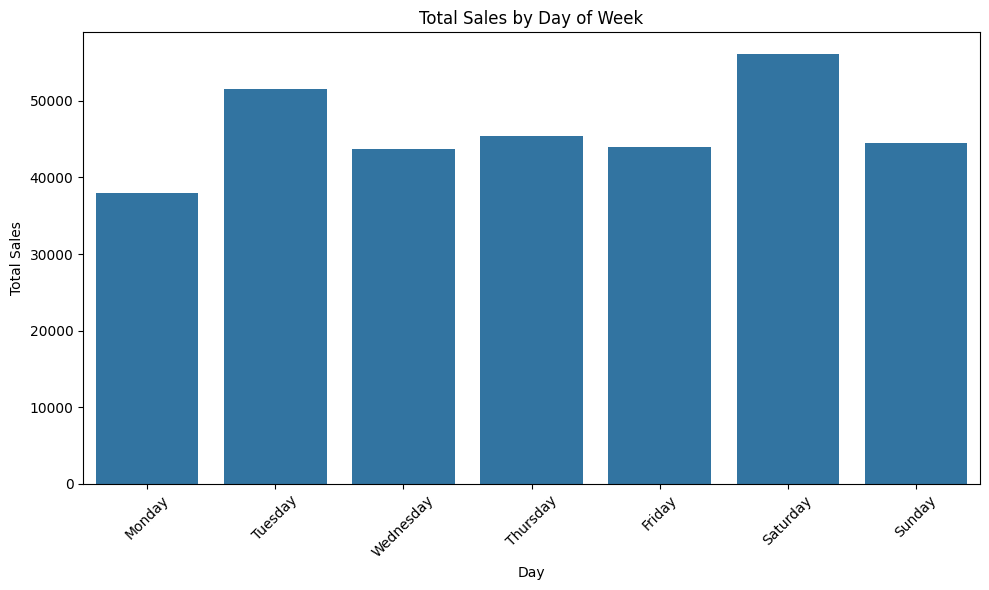

In [185]:
plt.figure(figsize=(10, 6))

sns.barplot(
    x=daily_sales.index,
    y=daily_sales.values
)

plt.title("Total Sales by Day of Week")
plt.xlabel("Day")
plt.ylabel("Total Sales")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# **Time-Based Patterns**

The analysis examined total sales and transaction volume by hour.
- The peak sales hour was 19.
- The lowest sales hour was 20.

 The analysis also compared sales performance across days of the week.
- The highest-sales day was Saturday.
- The lowest-sales day was Monday.

# **11. Overall Conclusion**

This exploratory data analysis examined 1,000 supermarket transactions to understand sales performance, customer behavior, product performance, payment patterns, time-based trends, relationships between variables, and potential anomalies.

### Main Findings

* **Food and beverages** generated the highest total sales, while **health and beauty** generated the lowest total sales.
* **Electronic accessories** recorded the highest quantity sold, showing that the product line with the highest sales volume was not necessarily the product line with the highest total revenue.
* **Giza** recorded the highest total sales among the three branches, while Alex and Cairo had very similar sales totals.
* **Member customers** made more transactions and had a higher average transaction value than Normal customers.
* **E-wallet** was the most frequently used payment method, followed very closely by cash.
* There was a **positive correlation of 0.706 between Quantity and Sales**, indicating that higher quantities purchased were generally associated with higher transaction values.
* Several **high-value transactions** were identified as potential outliers. These should be investigated further before being classified as data errors.
* The analysis found a **constant gross margin percentage of 4.76%**, resulting in zero standard deviation for this variable.
* Time-based analysis showed that **19:00 was the peak sales hour**, while **20:00 was the lowest-sales hour** in the dataset.
* **Saturday** recorded the highest total sales by day of the week, while **Monday** recorded the lowest.

### Hypothesis Testing

An independent two-sample t-test was conducted to compare average transaction values between Member and Normal customers.

The test produced:

* **T-statistic:** 1.8862
* **P-value:** 0.05957
* **Significance level:** 0.05

Because the p-value is greater than 0.05, the null hypothesis was not rejected. Therefore, there is insufficient statistical evidence at the 5% significance level to conclude that the average transaction values of Member and Normal customers differ significantly.

### Data Quality Assessment

The dataset was examined for missing values, duplicate records, data types, categorical consistency, and unusual observations. Potential high-value outliers were identified for further investigation rather than automatically being classified as errors.

### Final Summary

The EDA revealed meaningful differences in product, branch, customer, payment, and time-based sales behavior. The analysis demonstrates how descriptive statistics, visualization, correlation analysis, outlier detection, and hypothesis testing can be combined to extract useful insights from transactional data.
